# 🔩 LS-DYNA `.k` → VTK Full Converter
> **Complete conversion — nodes, elements (hex/tet/penta/shell/beam), parts, materials, sets**

| Cell | Stage | Description |
|------|-------|-------------|
| 1 | Install | Dependencies |
| 2 | Config | Set input/output paths |
| 3 | Parser | Full `.k` keyword parser |
| 4 | Builder | Assemble VTK UnstructuredGrid |
| 5 | Writer | Save `.vtk` / `.vtu` + summary |
| 6 | Validate | Load-back check + stats |

### What is preserved
| Data | Preserved | Notes |
|------|-----------|-------|
| Node XYZ | ✅ full precision | float64 |
| Node IDs | ✅ | stored as point data field |
| Hex8 elements | ✅ | VTK_HEXAHEDRON (12) |
| Tet4 elements | ✅ | VTK_TETRA (10) |
| Penta6 elements | ✅ | VTK_WEDGE (13) |
| Shell quad4 | ✅ | VTK_QUAD (9) |
| Shell tria3 | ✅ | VTK_TRIANGLE (5) |
| Beam/truss | ✅ | VTK_LINE (3) |
| Part ID per element | ✅ | cell data field |
| Material ID per part | ✅ | cell data field |
| Node sets (*SET_NODE) | ✅ | point data boolean fields |
| Element sets (*SET_ELEMENT) | ✅ | cell data boolean fields |
| *MAT cards | ⚠️ | stored as VTK field data (metadata) |
| *SECTION cards | ⚠️ | stored as VTK field data (metadata) |
| Boundary conditions | ⚠️ | stored as VTK field data (metadata) |
| LS-DYNA solver logic | ❌ | not representable in VTK |

## ⚙️ Cell 1 — Install Dependencies

In [1]:
!pip install numpy pyvista vtk -q

import numpy as np
import pyvista as pv
import vtk
import os, re, json, time
from collections import defaultdict

print(f"✅ numpy  : {np.__version__}")
print(f"✅ pyvista: {pv.__version__}")
print(f"✅ vtk    : {vtk.vtkVersion.GetVTKVersion()}")

✅ numpy  : 1.22.4
✅ pyvista: 0.46.5
✅ vtk    : 9.5.2


## 📁 Cell 2 — User Config

In [2]:
# ── USER EDIT ────────────────────────────────────────────────────────────────
K_PATH     = '/home/asusry7/Desktop/New_version/New_version/Head_V6.k'   # input LS-DYNA .k file
OUTPUT_DIR = '/home/asusry7/Desktop/New_version/New_version/Data/outputs/vtk_export'   # output folder
OUT_FORMAT = 'vtu'   # 'vtk' = legacy ASCII/binary  |  'vtu' = modern XML (recommended)
BINARY_OUT = True    # True = binary (smaller, faster)  |  False = ASCII (human-readable)
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
stem = os.path.splitext(os.path.basename(K_PATH))[0]
OUT_PATH = os.path.join(OUTPUT_DIR, f"{stem}.{OUT_FORMAT}")

print(f"Input  : {K_PATH}   exists={os.path.exists(K_PATH)}")
print(f"Output : {OUT_PATH}")
print(f"Format : {OUT_FORMAT.upper()} ({'binary' if BINARY_OUT else 'ASCII'})")

Input  : /home/asusry7/Desktop/New_version/New_version/Head_V6.k   exists=True
Output : /home/asusry7/Desktop/New_version/New_version/Data/outputs/vtk_export/Head_V6.vtu
Format : VTU (binary)


## 🔩 Cell 3 — Full LS-DYNA `.k` Parser

Parses all major keyword blocks:
- `*NODE`
- `*ELEMENT_SOLID` (hex8, tet4, penta6)
- `*ELEMENT_SHELL` (quad4, tria3)
- `*ELEMENT_BEAM` / `*ELEMENT_TRUSS`
- `*PART`
- `*MAT_*` (all material types — stored as metadata)
- `*SECTION_*`
- `*SET_NODE` / `*SET_NODE_LIST`
- `*SET_ELEMENT`
- `*BOUNDARY_SPC_NODE`

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# VTK cell type constants
# ─────────────────────────────────────────────────────────────────────────────
VTK_LINE     = 3
VTK_TRIANGLE = 5
VTK_QUAD     = 9
VTK_TETRA    = 10
VTK_WEDGE    = 13
VTK_HEX     = 12


# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def _split_fixed_or_csv(line, field_width=8, n_fields=None):
    """
    Return list of stripped string tokens from a .k line.
    Handles both comma-separated (free format) and fixed-width format.
    """
    stripped = line.rstrip('\n')
    if ',' in stripped:
        parts = [p.strip() for p in stripped.split(',')]
    else:
        parts = [stripped[i:i+field_width].strip()
                 for i in range(0, len(stripped), field_width)]
    if n_fields is not None:
        parts = parts[:n_fields]
    return parts


def _is_comment_or_blank(line):
    s = line.strip()
    return s == '' or s.startswith('$')


def _is_keyword(line):
    return line.lstrip().startswith('*')


# ─────────────────────────────────────────────────────────────────────────────
# Main parser
# ─────────────────────────────────────────────────────────────────────────────

def parse_k_full(k_path):
    """
    Full parse of an LS-DYNA keyword (.k) file.

    Returns
    -------
    data : dict with keys:
        nodes          : {nid: [x, y, z]}
        elements_solid : {eid: {'pid': int, 'nids': list[int], 'type': str}}
        elements_shell : {eid: {'pid': int, 'nids': list[int], 'type': str}}
        elements_beam  : {eid: {'pid': int, 'nids': list[int], 'type': str}}
        parts          : {pid: {'mid': int, 'secid': int, 'title': str}}
        materials      : {mid: {'type': str, 'params': dict}}
        sections       : {secid: {'type': str, 'params': dict}}
        node_sets      : {setid: list[nid]}
        element_sets   : {setid: list[eid]}
        boundary_spc   : list[dict]  (raw SPC constraint records)
        raw_metadata   : dict        (unparsed keyword text for archiving)
    """
    t0 = time.time()

    data = {
        'nodes':           {},
        'elements_solid':  {},
        'elements_shell':  {},
        'elements_beam':   {},
        'parts':           {},
        'materials':       {},
        'sections':        {},
        'node_sets':       {},
        'element_sets':    {},
        'boundary_spc':    [],
        'raw_metadata':    {},
    }

    with open(k_path, 'r', errors='replace') as fh:
        lines = fh.readlines()

    print(f"📂 Read {len(lines):,} lines from {k_path}")

    i = 0
    current_kw = None
    pending_part_title = ''   # buffered title line, attached to the *next* pid/secid/mid line

    while i < len(lines):
        line = lines[i]

        # ── New keyword card ──────────────────────────────────────────────────
        if _is_keyword(line):
            current_kw = line.strip().upper().split()[0]  # e.g. '*NODE', '*ELEMENT_SOLID'
            i += 1
            continue

        # ── Skip comments / blanks ────────────────────────────────────────────
        if _is_comment_or_blank(line):
            i += 1
            continue

        # ── Dispatch by keyword ───────────────────────────────────────────────

        # *NODE
        if current_kw == '*NODE':
            try:
                if ',' in line:
                    p = line.split(',')
                    nid = int(p[0])
                    x, y, z = float(p[1]), float(p[2]), float(p[3])
                else:
                    nid = int(line[0:8])
                    x   = float(line[8:24])
                    y   = float(line[24:40])
                    z   = float(line[40:56])
                data['nodes'][nid] = [x, y, z]
            except (ValueError, IndexError):
                pass

        # *ELEMENT_SOLID  — cols: EID PID N1 N2 N3 N4 N5 N6 N7 N8
        elif current_kw in ('*ELEMENT_SOLID', '*ELEMENT_SOLID_ORTHO',
                             '*ELEMENT_SOLID_PERI'):
            try:
                p = _split_fixed_or_csv(line, field_width=8, n_fields=10)
                eid = int(p[0]); pid = int(p[1])
                nids = [int(x) for x in p[2:] if x]
                # Classify by node count
                if len(nids) == 8:
                    etype = 'hex8'
                elif len(nids) == 4:
                    etype = 'tet4'
                elif len(nids) == 6:
                    etype = 'penta6'
                else:
                    etype = f'solid{len(nids)}'
                data['elements_solid'][eid] = {'pid': pid, 'nids': nids, 'type': etype}
            except (ValueError, IndexError):
                pass

        # *ELEMENT_SHELL  — cols: EID PID N1 N2 N3 N4
        elif current_kw in ('*ELEMENT_SHELL', '*ELEMENT_SHELL_BETA',
                             '*ELEMENT_SHELL_OFFSET', '*ELEMENT_TSHELL'):
            try:
                p = _split_fixed_or_csv(line, field_width=8, n_fields=6)
                eid = int(p[0]); pid = int(p[1])
                nids = [int(x) for x in p[2:] if x and x != '0']
                etype = 'quad4' if len(nids) == 4 else 'tria3'
                data['elements_shell'][eid] = {'pid': pid, 'nids': nids, 'type': etype}
            except (ValueError, IndexError):
                pass

        # *ELEMENT_BEAM / *ELEMENT_TRUSS — cols: EID PID N1 N2
        elif current_kw in ('*ELEMENT_BEAM', '*ELEMENT_TRUSS',
                             '*ELEMENT_CABLE', '*ELEMENT_DISCRETE'):
            try:
                p = _split_fixed_or_csv(line, field_width=8, n_fields=5)
                eid = int(p[0]); pid = int(p[1])
                nids = [int(p[2]), int(p[3])]
                data['elements_beam'][eid] = {'pid': pid, 'nids': nids, 'type': 'beam2'}
            except (ValueError, IndexError):
                pass

        # *PART  — header line: title (optional), then: pid secid mid ...
        # NOTE: the title line always comes BEFORE the pid/secid/mid line, so it
        # cannot be attributed to any pid yet when it's read. Buffer it in
        # pending_part_title and attach it to whichever pid line comes next —
        # attaching it to `last_pid` (the previously-parsed part) was the bug:
        # every part's title ended up stored one part early, on its predecessor.
        elif current_kw == '*PART':
            try:
                # This data line may be a title string (non-numeric) -- if it
                # parses as pid/secid/mid, consume the buffered title for it.
                p = _split_fixed_or_csv(line, field_width=10, n_fields=8)
                pid = int(p[0])
                secid = int(p[1]) if len(p) > 1 and p[1] else 0
                mid   = int(p[2]) if len(p) > 2 and p[2] else 0
                data['parts'][pid] = {'mid': mid, 'secid': secid, 'title': pending_part_title}
                pending_part_title = ''
            except (ValueError, IndexError):
                # It's the title line — buffer it for the pid line that follows
                pending_part_title = line.strip()

        # *PART_TITLE — title on same line as part card
        elif current_kw == '*PART_TITLE':
            # Line 1: title text
            title_line = line.strip()
            i += 1
            # Line 2: pid secid mid
            while i < len(lines) and _is_comment_or_blank(lines[i]):
                i += 1
            if i < len(lines):
                try:
                    p = _split_fixed_or_csv(lines[i], field_width=10, n_fields=8)
                    pid   = int(p[0])
                    secid = int(p[1]) if len(p) > 1 and p[1] else 0
                    mid   = int(p[2]) if len(p) > 2 and p[2] else 0
                    data['parts'][pid] = {'mid': mid, 'secid': secid, 'title': title_line}
                except (ValueError, IndexError):
                    pass

        # *MAT_*  — store type + raw parameter text
        elif current_kw and current_kw.startswith('*MAT'):
            mat_type = current_kw
            # First data line has mid as first field
            try:
                p = _split_fixed_or_csv(line, field_width=10)
                mid = int(p[0])
                param_str = line.strip()
                if mid not in data['materials']:
                    data['materials'][mid] = {'type': mat_type, 'params': {}}
                data['materials'][mid]['params']['line0'] = param_str
            except (ValueError, IndexError):
                pass

        # *SECTION_*  — store type + raw parameter text
        elif current_kw and current_kw.startswith('*SECTION'):
            try:
                p = _split_fixed_or_csv(line, field_width=10)
                secid = int(p[0])
                if secid not in data['sections']:
                    data['sections'][secid] = {'type': current_kw, 'params': {}}
                data['sections'][secid]['params']['line0'] = line.strip()
            except (ValueError, IndexError):
                pass

        # *SET_NODE_LIST or *SET_NODE  — collect node IDs (may span multiple lines)
        elif current_kw in ('*SET_NODE', '*SET_NODE_LIST',
                             '*SET_NODE_ADD', '*SET_NODE_GENERAL'):
            try:
                p = _split_fixed_or_csv(line, field_width=8)
                setid = int(p[0])
                if setid not in data['node_sets']:
                    data['node_sets'][setid] = []
                # Read subsequent lines of node IDs
                i += 1
                while i < len(lines) and not _is_keyword(lines[i]):
                    if not _is_comment_or_blank(lines[i]):
                        ids = _split_fixed_or_csv(lines[i], field_width=8)
                        data['node_sets'][setid].extend(
                            int(x) for x in ids if x and x != '0'
                        )
                    i += 1
                continue  # i already advanced
            except (ValueError, IndexError):
                pass

        # *SET_ELEMENT_LIST etc.
        elif current_kw in ('*SET_ELEMENT', '*SET_ELEMENT_LIST',
                             '*SET_ELEMENT_ADD'):
            try:
                p = _split_fixed_or_csv(line, field_width=8)
                setid = int(p[0])
                if setid not in data['element_sets']:
                    data['element_sets'][setid] = []
                i += 1
                while i < len(lines) and not _is_keyword(lines[i]):
                    if not _is_comment_or_blank(lines[i]):
                        ids = _split_fixed_or_csv(lines[i], field_width=8)
                        data['element_sets'][setid].extend(
                            int(x) for x in ids if x and x != '0'
                        )
                    i += 1
                continue
            except (ValueError, IndexError):
                pass

        # *BOUNDARY_SPC_NODE  — cols: NID CID DOFX DOFY DOFZ DOFRX DOFRY DOFRZ
        elif current_kw in ('*BOUNDARY_SPC_NODE', '*BOUNDARY_SPC_SET'):
            try:
                p = _split_fixed_or_csv(line, field_width=8, n_fields=8)
                data['boundary_spc'].append({
                    'nid':   int(p[0]),
                    'dofs':  [int(x) for x in p[2:8] if x]
                })
            except (ValueError, IndexError):
                pass

        i += 1

    # ── Summary ───────────────────────────────────────────────────────────────
    elapsed = time.time() - t0
    print(f"\n✅ Parse complete in {elapsed:.2f}s")
    print(f"   Nodes           : {len(data['nodes']):>10,}")
    print(f"   Solid elements  : {len(data['elements_solid']):>10,}")
    print(f"   Shell elements  : {len(data['elements_shell']):>10,}")
    print(f"   Beam elements   : {len(data['elements_beam']):>10,}")
    print(f"   Parts           : {len(data['parts']):>10,}")
    print(f"   Materials       : {len(data['materials']):>10,}")
    print(f"   Sections        : {len(data['sections']):>10,}")
    print(f"   Node sets       : {len(data['node_sets']):>10,}")
    print(f"   Element sets    : {len(data['element_sets']):>10,}")
    print(f"   SPC constraints : {len(data['boundary_spc']):>10,}")

    return data


# ── Run parser ────────────────────────────────────────────────────────────────
kdata = parse_k_full(K_PATH)

📂 Read 439,995 lines from /home/asusry7/Desktop/New_version/New_version/Head_V6.k

✅ Parse complete in 1.87s
   Nodes           :    179,676
   Solid elements  :    176,441
   Shell elements  :     80,130
   Beam elements   :          0
   Parts           :        257
   Materials       :        126
   Sections        :        125
   Node sets       :          0
   Element sets    :          0
   SPC constraints :          0


## 🏗️ Cell 4 — Build VTK UnstructuredGrid

Assembles a `pyvista.UnstructuredGrid` from the parsed data:
- All element types in one grid (multi-block if needed)
- Point data fields: `node_id`, per-node-set booleans, `has_spc`
- Cell data fields: `element_id`, `part_id`, `material_id`, `section_id`, `element_type`, per-element-set booleans

In [4]:
def build_vtk_grid(kdata):
    """
    Convert parsed .k data into a pyvista.UnstructuredGrid.

    All element types (solid, shell, beam) are merged into one grid.
    Point data and cell data arrays encode every attribute.
    """
    nodes  = kdata['nodes']
    parts  = kdata['parts']

    if not nodes:
        raise ValueError("No nodes found — check that K_PATH is correct.")

    # ── 1. Build ordered node array + ID→index map ────────────────────────────
    node_ids_sorted = sorted(nodes.keys())
    nid_to_idx      = {nid: idx for idx, nid in enumerate(node_ids_sorted)}
    points          = np.array([nodes[nid] for nid in node_ids_sorted], dtype=np.float64)
    n_pts           = len(points)
    print(f"🔢 Building grid: {n_pts:,} points")

    # ── 2. Collect all elements ───────────────────────────────────────────────
    # Each entry: (vtk_type, connectivity_list, eid, pid)
    all_cells  = []   # flat VTK connectivity array entries
    cell_types = []
    cell_eid   = []
    cell_pid   = []
    cell_etype = []   # string label for element type

    def _add_elements(elem_dict, vtk_type_map):
        for eid, el in elem_dict.items():
            etype = el['type']
            vtype = vtk_type_map.get(etype)
            if vtype is None:
                continue   # unsupported type
            nids = el['nids']
            try:
                indices = [nid_to_idx[n] for n in nids]
            except KeyError:
                continue   # node referenced but not defined — skip
            all_cells.append(len(indices))
            all_cells.extend(indices)
            cell_types.append(vtype)
            cell_eid.append(eid)
            cell_pid.append(el['pid'])
            cell_etype.append(etype)

    solid_map = {'hex8': VTK_HEX, 'tet4': VTK_TETRA, 'penta6': VTK_WEDGE}
    shell_map = {'quad4': VTK_QUAD, 'tria3': VTK_TRIANGLE}
    beam_map  = {'beam2': VTK_LINE}

    _add_elements(kdata['elements_solid'], solid_map)
    _add_elements(kdata['elements_shell'], shell_map)
    _add_elements(kdata['elements_beam'],  beam_map)

    if not all_cells:
        raise ValueError("No elements could be mapped — check element blocks in .k file.")

    n_cells = len(cell_types)
    print(f"   {n_cells:,} elements mapped")

    # ── 3. Construct pyvista UnstructuredGrid ─────────────────────────────────
    cells_arr = np.array(all_cells, dtype=np.int64)
    ctypes_arr = np.array(cell_types, dtype=np.uint8)

    grid = pv.UnstructuredGrid(cells_arr, ctypes_arr, points)

    # ── 4. Point data ─────────────────────────────────────────────────────────
    # node_id — original LS-DYNA node ID
    grid.point_data['node_id'] = np.array(node_ids_sorted, dtype=np.int64)

    # Node sets — one boolean array per set
    for setid, nid_list in kdata['node_sets'].items():
        arr = np.zeros(n_pts, dtype=np.uint8)
        for nid in nid_list:
            if nid in nid_to_idx:
                arr[nid_to_idx[nid]] = 1
        grid.point_data[f'node_set_{setid}'] = arr

    # SPC constraints — flag nodes with any boundary condition
    if kdata['boundary_spc']:
        spc_arr = np.zeros(n_pts, dtype=np.uint8)
        for rec in kdata['boundary_spc']:
            nid = rec['nid']
            if nid in nid_to_idx:
                spc_arr[nid_to_idx[nid]] = 1
        grid.point_data['has_spc'] = spc_arr

    # ── 5. Cell data ──────────────────────────────────────────────────────────
    grid.cell_data['element_id']   = np.array(cell_eid, dtype=np.int64)
    grid.cell_data['part_id']      = np.array(cell_pid, dtype=np.int32)

    # material_id and section_id from part lookup
    mat_ids  = [parts[pid]['mid']   if pid in parts else -1 for pid in cell_pid]
    sec_ids  = [parts[pid]['secid'] if pid in parts else -1 for pid in cell_pid]
    grid.cell_data['material_id']  = np.array(mat_ids, dtype=np.int32)
    grid.cell_data['section_id']   = np.array(sec_ids, dtype=np.int32)

    # element_type as integer code for easy coloring
    type_code_map = {'hex8': 0, 'tet4': 1, 'penta6': 2,
                     'quad4': 3, 'tria3': 4, 'beam2': 5}
    grid.cell_data['element_type_code'] = np.array(
        [type_code_map.get(t, -1) for t in cell_etype], dtype=np.int8
    )

    # Element sets — one boolean array per set
    eid_to_cell = {eid: idx for idx, eid in enumerate(cell_eid)}
    for setid, eid_list in kdata['element_sets'].items():
        arr = np.zeros(n_cells, dtype=np.uint8)
        for eid in eid_list:
            if eid in eid_to_cell:
                arr[eid_to_cell[eid]] = 1
        grid.cell_data[f'element_set_{setid}'] = arr

    # ── 6. Field data (metadata — materials, sections, parts) ─────────────────
    # Store as JSON strings in VTK field data
    parts_json = json.dumps({
        str(pid): v for pid, v in kdata['parts'].items()
    })
    mats_json = json.dumps({
        str(mid): {'type': v['type']} for mid, v in kdata['materials'].items()
    })
    secs_json = json.dumps({
        str(sid): {'type': v['type']} for sid, v in kdata['sections'].items()
    })

    grid.field_data['parts_json']    = np.array([parts_json])
    grid.field_data['materials_json'] = np.array([mats_json])
    grid.field_data['sections_json'] = np.array([secs_json])
    grid.field_data['source_file']   = np.array([K_PATH])

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n✅ VTK UnstructuredGrid built")
    print(f"   Points          : {grid.n_points:,}")
    print(f"   Cells           : {grid.n_cells:,}")
    print(f"   Point arrays    : {list(grid.point_data.keys())}")
    print(f"   Cell  arrays    : {list(grid.cell_data.keys())}")
    print(f"   Field data      : {list(grid.field_data.keys())}")
    bounds = grid.bounds
    print(f"   Bounds X        : [{bounds[0]:.3f}, {bounds[1]:.3f}]")
    print(f"   Bounds Y        : [{bounds[2]:.3f}, {bounds[3]:.3f}]")
    print(f"   Bounds Z        : [{bounds[4]:.3f}, {bounds[5]:.3f}]")

    return grid


# ── Run ───────────────────────────────────────────────────────────────────────
grid = build_vtk_grid(kdata)

🔢 Building grid: 179,676 points
   256,571 elements mapped

✅ VTK UnstructuredGrid built
   Points          : 179,676
   Cells           : 256,571
   Point arrays    : ['node_id']
   Cell  arrays    : ['element_id', 'part_id', 'material_id', 'section_id', 'element_type_code']
   Field data      : ['parts_json', 'materials_json', 'sections_json', 'source_file']
   Bounds X        : [-283.356, -52.307]
   Bounds Y        : [-82.595, 82.595]
   Bounds Z        : [519.142, 770.890]


## 💾 Cell 5 — Write VTK File + Export Summary

In [5]:
t0 = time.time()

# ── Write main grid ───────────────────────────────────────────────────────────
grid.save(OUT_PATH, binary=BINARY_OUT)
fsize_mb = os.path.getsize(OUT_PATH) / 1e6
print(f"✅ Saved: {OUT_PATH}  ({fsize_mb:.1f} MB)  in {time.time()-t0:.2f}s")

# ── Per-part VTK files (optional — one .vtk per part) ────────────────────────
EXPORT_PER_PART = True   # ← set False to skip

if EXPORT_PER_PART and kdata['parts']:
    parts_dir = os.path.join(OUTPUT_DIR, 'parts')
    os.makedirs(parts_dir, exist_ok=True)
    part_ids = np.unique(grid.cell_data['part_id'])
    print(f"\n🔀 Exporting {len(part_ids)} individual part files...")
    for pid in part_ids:
        mask = grid.cell_data['part_id'] == pid
        part_grid = grid.extract_cells(np.where(mask)[0])
        title = kdata['parts'].get(pid, {}).get('title', '').strip()
        safe_title = re.sub(r'[^\w]', '_', title)[:30] if title else ''
        fname = f"part_{pid:04d}{'_'+safe_title if safe_title else ''}.{OUT_FORMAT}"
        fpath = os.path.join(parts_dir, fname)
        part_grid.save(fpath, binary=BINARY_OUT)
        print(f"   part {pid:>6d} : {part_grid.n_points:>7,} pts  {part_grid.n_cells:>7,} cells → {fname}")

# ── Metadata sidecar JSON ─────────────────────────────────────────────────────
meta_path = os.path.join(OUTPUT_DIR, f"{stem}_metadata.json")
meta = {
    'source': K_PATH,
    'n_nodes': len(kdata['nodes']),
    'n_elements_solid': len(kdata['elements_solid']),
    'n_elements_shell': len(kdata['elements_shell']),
    'n_elements_beam': len(kdata['elements_beam']),
    'parts': {str(k): v for k, v in kdata['parts'].items()},
    'materials': {str(k): {'type': v['type']} for k, v in kdata['materials'].items()},
    'sections':  {str(k): {'type': v['type']} for k, v in kdata['sections'].items()},
    'node_sets': {str(k): len(v) for k, v in kdata['node_sets'].items()},
    'element_sets': {str(k): len(v) for k, v in kdata['element_sets'].items()},
    'n_spc_constraints': len(kdata['boundary_spc']),
}
with open(meta_path, 'w') as fh:
    json.dump(meta, fh, indent=2)
print(f"\n📋 Metadata sidecar: {meta_path}")

# ── File list ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("📦 OUTPUT FILES:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        fsize = os.path.getsize(fpath) / 1e6
        rel   = os.path.relpath(fpath, OUTPUT_DIR)
        print(f"   {rel:<55} {fsize:.1f} MB")
print("="*55)

✅ Saved: /home/asusry7/Desktop/New_version/New_version/Data/outputs/vtk_export/Head_V6.vtu  (9.7 MB)  in 0.89s

🔀 Exporting 229 individual part files...
   part 8898100 :     128 pts      112 cells → part_8898100_Joint.vtu
   part 88000001 :   1,624 pts      789 cells → part_88000001_frontal_r.vtu
   part 88000002 :     815 pts      786 cells → part_88000002_frontal_external_r.vtu
   part 88000003 :     795 pts      753 cells → part_88000003_frontal_internal_r.vtu
   part 88000004 :   2,952 pts    1,430 cells → part_88000004_parietal_r.vtu
   part 88000005 :   1,476 pts    1,430 cells → part_88000005_parietal_external_r.vtu
   part 88000006 :   1,476 pts    1,430 cells → part_88000006_parietal_internal_r.vtu
   part 88000007 :   1,883 pts    1,598 cells → part_88000007_temporal_r.vtu
   part 88000008 :       6 pts        2 cells → part_88000008_temporal_shell_r.vtu
   part 88000009 :     769 pts      855 cells → part_88000009_temporal_external_r.vtu
   part 88000010 :     742 pts      

## ✅ Cell 6 — Load-back Validation + Quick Stats

🔍 Loading back VTK file for validation...
✅ Point count : 179,676  (matches)
✅ Cell  count : 256,571  (matches)
✅ Max coordinate round-trip error: 0.00e+00 mm  (PASS)


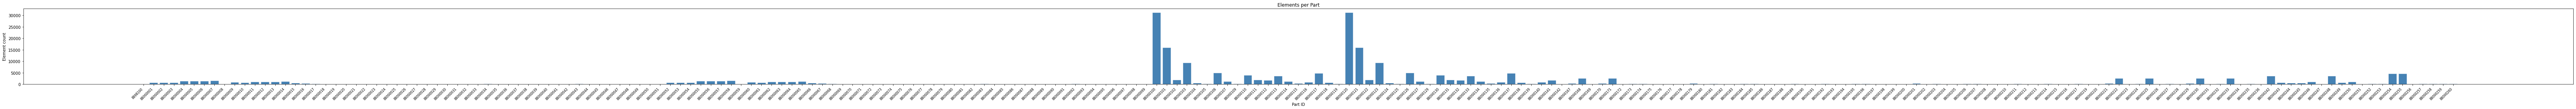


📊 Part distribution chart saved: /home/asusry7/Desktop/New_version/New_version/Data/outputs/vtk_export/part_distribution.png

📐 Element type breakdown:
   hex8       :    176,441
   quad4      :     80,130

🎯 Validation complete. File is clean and ready for:
   → 3D Slicer  (import as UnstructuredGrid)
   → ParaView   (open directly)
   → SimpleITK  (pv.read → extract surface → sitk)
   → Registration pipeline (our CT_MRI_Registration_K_Mesh.ipynb)


In [6]:
import matplotlib.pyplot as plt

print("🔍 Loading back VTK file for validation...")
grid_check = pv.read(OUT_PATH)

# ── Node count match ──────────────────────────────────────────────────────────
assert grid_check.n_points == grid.n_points, \
    f"Point count mismatch: {grid_check.n_points} vs {grid.n_points}"
assert grid_check.n_cells == grid.n_cells, \
    f"Cell count mismatch: {grid_check.n_cells} vs {grid.n_cells}"
print(f"✅ Point count : {grid_check.n_points:,}  (matches)")
print(f"✅ Cell  count : {grid_check.n_cells:,}  (matches)")

# ── Coordinate round-trip error ───────────────────────────────────────────────
orig_pts  = grid.points
check_pts = grid_check.points
max_err   = np.max(np.abs(orig_pts - check_pts))
print(f"✅ Max coordinate round-trip error: {max_err:.2e} mm  "
      f"({'PASS' if max_err < 1e-6 else 'WARN — check binary flag'})")

# ── Part distribution bar chart ───────────────────────────────────────────────
part_ids_arr = grid_check.cell_data['part_id']
unique_pids, counts = np.unique(part_ids_arr, return_counts=True)

if len(unique_pids) > 0:
    fig, ax = plt.subplots(figsize=(max(6, len(unique_pids)*0.4), 4))
    ax.bar(unique_pids.astype(str), counts, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Part ID')
    ax.set_ylabel('Element count')
    ax.set_title('Elements per Part')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_DIR, 'part_distribution.png')
    plt.savefig(chart_path, dpi=120)
    plt.show()
    print(f"\n📊 Part distribution chart saved: {chart_path}")

# ── Element type breakdown ────────────────────────────────────────────────────
type_names = {0: 'hex8', 1: 'tet4', 2: 'penta6', 3: 'quad4', 4: 'tria3', 5: 'beam2'}
etype_arr  = grid_check.cell_data['element_type_code']
print("\n📐 Element type breakdown:")
for code, name in type_names.items():
    n = int(np.sum(etype_arr == code))
    if n > 0:
        print(f"   {name:<10} : {n:>10,}")

# ── Node set summary ──────────────────────────────────────────────────────────
nset_keys = [k for k in grid_check.point_data.keys() if k.startswith('node_set_')]
if nset_keys:
    print(f"\n🏷️  Node sets in VTK:")
    for k in nset_keys:
        n = int(np.sum(grid_check.point_data[k]))
        print(f"   {k:<30} : {n:>8,} nodes")

print("\n🎯 Validation complete. File is clean and ready for:")
print("   → 3D Slicer  (import as UnstructuredGrid)")
print("   → ParaView   (open directly)")
print("   → SimpleITK  (pv.read → extract surface → sitk)")
print("   → Registration pipeline (our CT_MRI_Registration_K_Mesh.ipynb)")